<a href="https://colab.research.google.com/github/Nicobg007/IA_2025/blob/main/dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving house_prices_large.csv to house_prices_large.csv
Dimensiones del dataset: (1000, 2)
Columnas: ['House_Size', 'Price']
   House_Size       Price
0  143.635030  417.428104
1  287.678577  601.054220
2  232.998485  588.407166
3  199.664621  539.925605
4   89.004660  338.197911

--- Estadísticas ---
        House_Size        Price
count  1000.000000  1000.000000
mean    172.564138   465.560240
std      73.034340   138.321107
min      51.158006   140.530316
25%     108.993317   350.214351
50%     174.201844   467.430606
75%     236.079897   578.569767
max     299.929418   795.230140

--- Correlaciones ---
            House_Size     Price
House_Size    1.000000  0.934065
Price         0.934065  1.000000


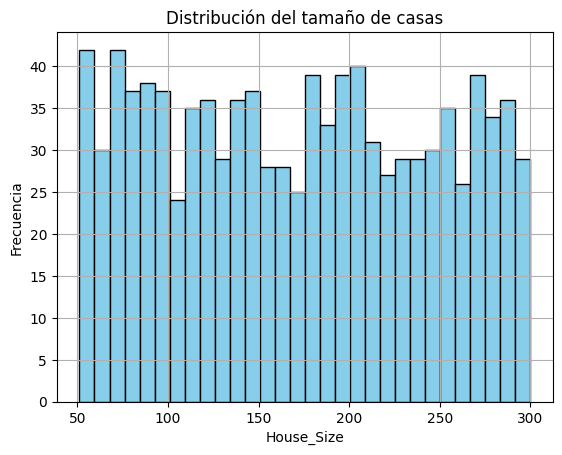

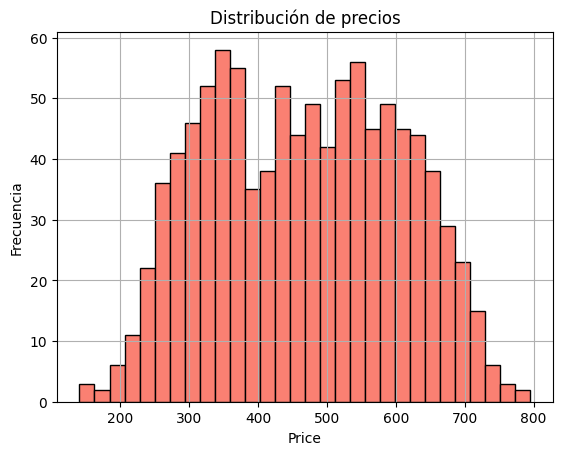

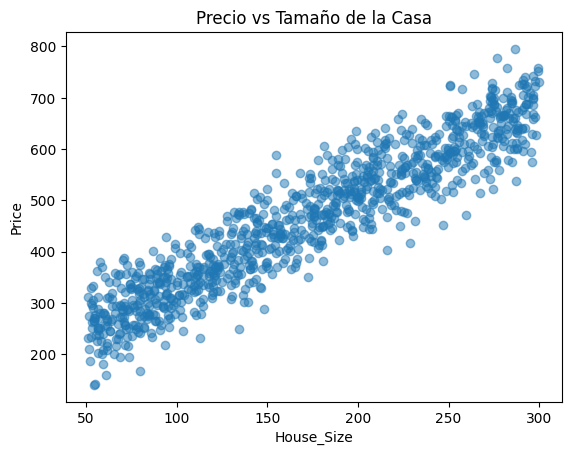


--- Modelo Lineal ---
Ecuación: Price ≈ 160.29 + 1.77 × House_Size
R²: 0.8724771770330358


TypeError: got an unexpected keyword argument 'squared'

In [ ]:
# ============================================
# ANALISIS DE DATOS Y REGRESION LINEAL - HOUSING
# Listo para Google Colab
# ============================================

# 1. Importar librerías
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# 2. Subir dataset a Colab
# (ejecuta esto y selecciona tu archivo CSV desde tu PC)
from google.colab import files
uploaded = files.upload()

# Cargar dataset
df = pd.read_csv("house_prices_large.csv")  # cambia el nombre si tu archivo tiene otro
print("Dimensiones del dataset:", df.shape)
print("Columnas:", df.columns.tolist())
print(df.head())

# 3. EDA (Exploratory Data Analysis)
print("\n--- Estadísticas ---")
print(df.describe())

print("\n--- Correlaciones ---")
print(df.corr(numeric_only=True))

# Graficar histogramas
df["House_Size"].hist(bins=30, color="skyblue", edgecolor="black")
plt.title("Distribución del tamaño de casas")
plt.xlabel("House_Size")
plt.ylabel("Frecuencia")
plt.show()

df["Price"].hist(bins=30, color="salmon", edgecolor="black")
plt.title("Distribución de precios")
plt.xlabel("Price")
plt.ylabel("Frecuencia")
plt.show()

# Gráfico Precio vs Tamaño
plt.scatter(df["House_Size"], df["Price"], alpha=0.5)
plt.xlabel("House_Size")
plt.ylabel("Price")
plt.title("Precio vs Tamaño de la Casa")
plt.show()

# 4. Modelo de Regresión Lineal
X = df[["House_Size"]]   # variable independiente
y = df["Price"]          # variable dependiente

model = LinearRegression()
model.fit(X, y)

print("\n--- Modelo Lineal ---")
print(f"Ecuación: Price ≈ {model.intercept_:.2f} + {model.coef_[0]:.2f} × House_Size")

# Evaluación del modelo
y_pred = model.predict(X)
print("R²:", r2_score(y, y_pred))
print("RMSE:", mean_squared_error(y, y_pred, squared=False))

# Línea de regresión en el gráfico
plt.scatter(X, y, alpha=0.5, label="Datos")
plt.plot(X, y_pred, color="red", linewidth=2, label="Regresión")
plt.xlabel("House_Size")
plt.ylabel("Price")
plt.legend()
plt.title("Regresión lineal: Precio vs Tamaño")
plt.show()

# 5. Predicciones: Casa de 4 habitaciones (usando tamaños supuestos)
sizes = {
    "Pequeña (120 m²)": 120,
    "Típica (170 m²)": 170,
    "Grande (220 m²)": 220
}

print("\n--- Predicciones para casa de 4 habitaciones ---")
for label, size in sizes.items():
    pred_price = model.predict([[size]])[0]
    print(f"{label}: {pred_price:.2f}")

# 6. (Opcional) Predicción con input manual
print("\n--- Predicción personalizada ---")
custom_size = float(input("Ingresa el tamaño de la casa en m²: "))
custom_price = model.predict([[custom_size]])[0]
print(f"Una casa de {custom_size} m² costaría aproximadamente: {custom_price:.2f}")